In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# ==========================================
# 0. preparing
# ==========================================
CONFIG = {
    'file_path': 'Adidas_US_Sales_Dataset.csv',
    'date_col': 'invoicedate',
    'target_col': 'totalsales',
    'look_back': 60,
    'batch_size': 16,
    'epochs': 100,
    'learning_rate': 0.0005,
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

print(f"using: {CONFIG['device']}")

using: cpu


In [3]:
# ==========================================
# 1. Data Cleaning
# ==========================================
def load_and_clean_data(config):
    # A. Read data
    try:
        df = pd.read_csv(config['file_path'], sep=None, engine='python')
    except Exception as e:
        print(f"fail: {e}")
        df = pd.read_csv(config['file_path'])  # Fallback

    # B. Column name standardisation (removing any spaces present in column names)
    df.columns = df.columns.str.lower().str.replace(' ', '')

    # Verify whether the listed entry exists
    if config['date_col'] not in df.columns or config['target_col'] not in df.columns:
        raise ValueError(f"List mismatch!: {df.columns.tolist()}")

    # C. Cleaning the 'totalsales' column (crucial step!)
    # The raw data may be in the format "$12 345", requiring the removal of the '$' and ' '.
    if df[config['target_col']].dtype == 'object':
        df[config['target_col']] = df[config['target_col']].astype(str).str.replace(r'[$\s,]', '', regex=True)
        df[config['target_col']] = pd.to_numeric(df[config['target_col']])

    # D. Date of analysis
    df[config['date_col']] = pd.to_datetime(df[config['date_col']], format='%d/%m/%Y', errors='coerce')
    if df[config['date_col']].isnull().all():
        df[config['date_col']] = pd.to_datetime(df[config['date_col']])

    # E. Aggregation
    # The raw data is "per order", and we need to forecast "total daily sales".
    daily_df = df.groupby(config['date_col'])[config['target_col']].sum().reset_index()

    # F. Resampling
    # Sales data frequently exhibits gaps and must be completed to form a continuous time series.
    daily_df = daily_df.set_index(config['date_col'])
    daily_df = daily_df.resample('D').sum().fillna(0)
    daily_df = daily_df.reset_index()

    return daily_df

In [4]:
# Execute cleaning and loading
df_clean = load_and_clean_data(CONFIG)
print("Data Preview (First 5 Rows):")
print(df_clean.head())
print(f"Total number of days: {len(df_clean)}")

Data Preview (First 5 Rows):
  invoicedate  totalsales
0  2020-01-01      845141
1  2020-01-02      689410
2  2020-01-03      632573
3  2020-01-04      615080
4  2020-01-05      707829
Total number of days: 731


In [5]:
# ==========================================
# 2. Feature Engineering
# ==========================================
def process_features(df, config):
    data = df.copy()
    target = config['target_col']

    # A. Smoothing (EWMA) - Reduces noise while preserving trends
    smooth_col = f"{target}_smooth"
    data[smooth_col] = data[target].ewm(span=7, adjust=False).mean()

    # B. Lag Features
    data['lag_1'] = data[smooth_col].shift(1)
    data['lag_7'] = data[smooth_col].shift(7)

    # C. Time Embeddings
    # Map the months and days of the week onto the circular ring (sin/cos)
    date_series = data[config['date_col']]
    data['month_sin'] = np.sin(2 * np.pi * date_series.dt.month / 12)
    data['month_cos'] = np.cos(2 * np.pi * date_series.dt.month / 12)
    data['day_sin'] = np.sin(2 * np.pi * date_series.dt.dayofweek / 7)
    data['day_cos'] = np.cos(2 * np.pi * date_series.dt.dayofweek / 7)

    data.dropna(inplace=True)

    # Define the feature columns for final use
    feature_cols = [smooth_col, 'lag_1', 'lag_7', 'month_sin', 'month_cos', 'day_sin', 'day_cos']

    return data, feature_cols


In [6]:
df_processed, feature_cols = process_features(df_clean, CONFIG)

In [7]:
# ==========================================
# 3. Sliding Window
# ==========================================
scaler = MinMaxScaler(feature_range=(0, 1))
data_values = df_processed[feature_cols].values
data_scaled = scaler.fit_transform(data_values)

def create_dataset_with_covariates(dataset, look_back):
    X_hist, X_target_cov, Y = [], [], []
    for i in range(len(dataset) - look_back):
        # 过去 60 天的历史数据
        X_hist.append(dataset[i: i + look_back])
        
        # Extract the date features for the target date (day i + look_back) 
        # The column indices corresponding to (month_sin, month_cos, day_sin, day_cos) are 3, 4, 5 and 6
        X_target_cov.append(dataset[i + look_back, 3:7])
        
        # Forecast target: Today’s Zoom sales – Yesterday’s Zoom sales
        delta_y = dataset[i + look_back, 0] - dataset[i + look_back - 1, 0]
        Y.append(delta_y)  
    return np.array(X_hist), np.array(X_target_cov), np.array(Y)

X_hist, X_target_cov, y = create_dataset_with_covariates(data_scaled, CONFIG['look_back'])

# Split the training set and test set
train_size = int(len(X_hist) * 0.85)

X_train_hist = torch.FloatTensor(X_hist[:train_size]).to(CONFIG['device'])
X_train_cov = torch.FloatTensor(X_target_cov[:train_size]).to(CONFIG['device'])
y_train = torch.FloatTensor(y[:train_size]).unsqueeze(1).to(CONFIG['device'])

X_test_hist = torch.FloatTensor(X_hist[train_size:]).to(CONFIG['device'])
X_test_cov = torch.FloatTensor(X_target_cov[train_size:]).to(CONFIG['device'])
y_test = torch.FloatTensor(y[train_size:]).unsqueeze(1).to(CONFIG['device'])

train_loader = DataLoader(TensorDataset(X_train_hist, X_train_cov, y_train), batch_size=CONFIG['batch_size'], shuffle=True)

In [8]:
# ==========================================
# 4. Model Definition
# ==========================================
class MultiScaleCNN_Covariates(nn.Module):
    def __init__(self, num_features, sequence_length, num_target_covariates=4):
        super(MultiScaleCNN_Covariates, self).__init__()

        self.out_seq_len = sequence_length // 2

        self.branch1 = nn.Sequential(
            nn.Conv1d(num_features, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Flatten()
        )

        self.branch2 = nn.Sequential(
            nn.Conv1d(num_features, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Flatten()
        )

        self.branch3 = nn.Sequential(
            nn.Conv1d(num_features, 32, kernel_size=45, padding=22),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Flatten()
        )

        # Fusion layer input: Features extracted by the CNN concatenated with covariate features from the target day (4 features)
        cnn_out_dim = (64 + 64 + 32) * self.out_seq_len
        linear_input_dim = cnn_out_dim + num_target_covariates

        self.regressor = nn.Sequential(
            nn.Linear(linear_input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x_hist, x_target_cov):
        x_in = x_hist.permute(0, 2, 1)

        out1 = self.branch1(x_in)
        out2 = self.branch2(x_in)
        out3 = self.branch3(x_in)

        # Features of a convolutional neural network (CNN)
        cnn_combined = torch.cat((out1, out2, out3), dim=1)
        
        # [New Core Feature] Concatenate the extracted historical features with tomorrow’s day of the week and month features!
        final_combined = torch.cat((cnn_combined, x_target_cov), dim=1)

        delta = self.regressor(final_combined)
        return delta

In [9]:
model = MultiScaleCNN_Covariates(num_features=X_train_hist.shape[2], sequence_length=CONFIG['look_back'], num_target_covariates=4).to(CONFIG['device'])
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=1e-5)

D:\anaconda\Lib\site-packages\triton\knobs.py:212: UserWarning: Failed to find cuobjdump.exe
  warnings.warn(f"Failed to find {binary}")
D:\anaconda\Lib\site-packages\triton\knobs.py:212: UserWarning: Failed to find nvdisasm.exe
  warnings.warn(f"Failed to find {binary}")


In [10]:
# ==========================================
# 5. Training cycle
# ==========================================
print("Commencing training...")
history_loss = []

for epoch in range(CONFIG['epochs']):
    model.train()
    batch_losses = []

    # batch_X_hist, batch_X_cov, batch_y
    for batch_X_hist, batch_X_cov, batch_y in train_loader:
        optimizer.zero_grad()
        
        # The model inputs have become two
        predictions = model(batch_X_hist, batch_X_cov)
        
        loss = criterion(predictions, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    avg_loss = np.mean(batch_losses)
    history_loss.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{CONFIG['epochs']} | Loss: {avg_loss:.6f}")

Commencing training...
Epoch 10/100 | Loss: 0.003928
Epoch 20/100 | Loss: 0.003360
Epoch 30/100 | Loss: 0.002468
Epoch 40/100 | Loss: 0.002085
Epoch 50/100 | Loss: 0.002109
Epoch 60/100 | Loss: 0.001872
Epoch 70/100 | Loss: 0.001637
Epoch 80/100 | Loss: 0.001618
Epoch 90/100 | Loss: 0.001330
Epoch 100/100 | Loss: 0.001193


In [11]:
# ==========================================
# 6. Forecasting, Inverse Difference and Evaluation
# ==========================================
model.eval()
with torch.no_grad():
    test_pred_delta = model(X_test_hist, X_test_cov).cpu().numpy()

# Retrieve the scaled actual value for ‘yesterday’ from the test set
last_val_test = X_test_hist[:, -1, 0].cpu().numpy().reshape(-1, 1)

# Convert to absolute scale values
test_pred_scaled_abs = last_val_test + test_pred_delta
y_test_scaled_abs = last_val_test + y_test.cpu().numpy()

def inverse_transform(pred_array, scaler):
    dummy = np.zeros((len(pred_array), len(feature_cols)))
    dummy[:, 0] = pred_array.flatten()
    return scaler.inverse_transform(dummy)[:, 0]

# denormalisation
y_test_real = inverse_transform(y_test_scaled_abs, scaler)
test_pred_real = inverse_transform(test_pred_scaled_abs, scaler)

rmse = np.sqrt(mean_squared_error(y_test_real, test_pred_real))
mae = mean_absolute_error(y_test_real, test_pred_real)
r2 = r2_score(y_test_real,  test_pred_real)
print(f"\n[Test set results] RMSE: {rmse:.2f}, MAE: {mae:.2f}, R² Score: {r2:.4f}")


[Test set results] RMSE: 460696.84, MAE: 320519.07, R² Score: 0.7233


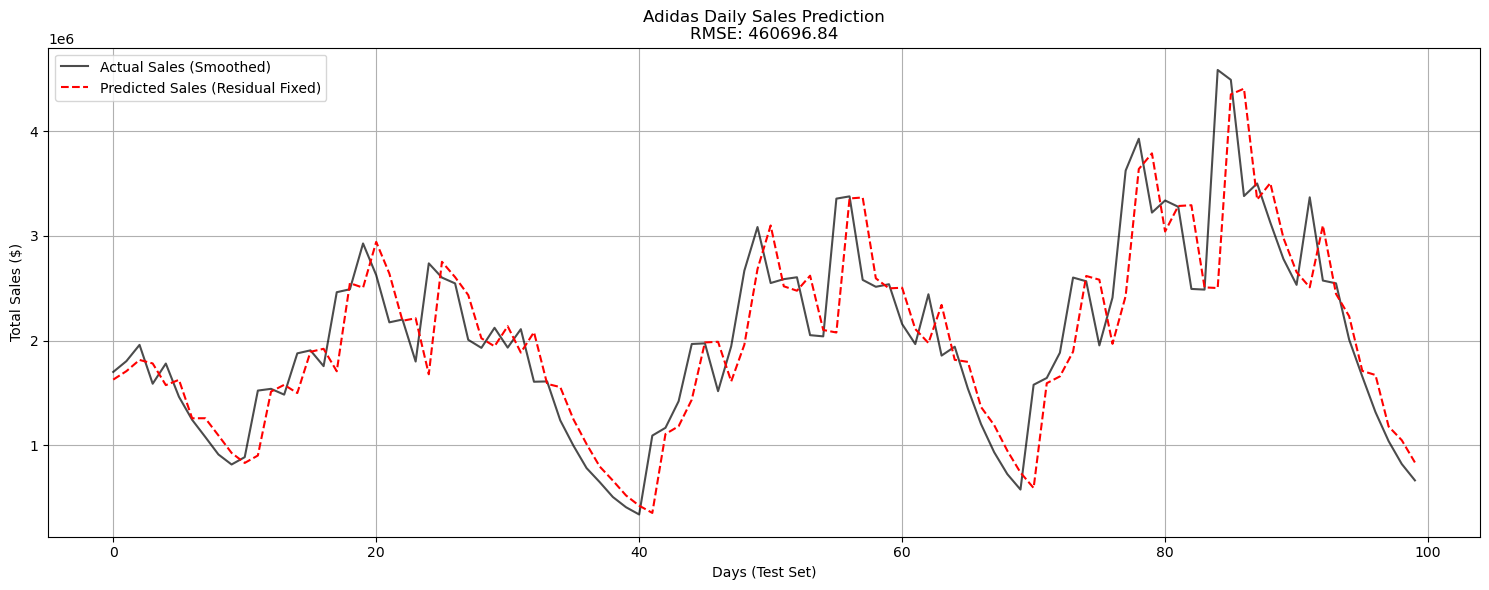

In [12]:
# ==========================================
# 7. Visualisation
# ==========================================
plt.figure(figsize=(15, 6))
plt.plot(y_test_real, label='Actual Sales (Smoothed)', color='black', alpha=0.7)
plt.plot(test_pred_real, label='Predicted Sales (Residual Fixed)', color='red', linestyle='--', linewidth=1.5)

plt.title(f'Adidas Daily Sales Prediction\nRMSE: {rmse:.2f}')
plt.xlabel('Days (Test Set)')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()